Лабораторная 2. Реализация сверточной нейронной сети для классификации цифр

Исходные данные - база MNIST (http://yann.lecun.com/exdb/mnist/). Обучающая выборка - 70%, тестовая - 30%.

Количество слоев, размерность свертки и гиперпараметры свертки и пулинга на Ваше усмотрение

Обучение - обратное распространение ошибки, средняя ошибка - 0,0001.

Должно быть реализовано:
- вычисление матрицы неточностей, по которой должны вычисляться показатели accuracy, precision, recall, F-мера, строится ROC-кривая, вычислятся AUC.
- t-SNE и оценить причины ошибочной классификации.

# Import

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc
from category_encoders import TargetEncoder

from pprint import pprint
from dotenv import load_dotenv

In [ ]:
load_dotenv()
PATH_DATA = Path(os.getenv('PATH_DATA'))
# sklearn.set_config(transform_output="pandas")
sklearn.set_config(transform_output="default")


from src.layers import ConvLayer, LinearLayer
from src.activations import ReLUActivation, SigmoidActivation
from src.losses import BCELoss
from src.data_loaders import ShuffleLoader, datasets
from src.optimizers import GDOptimizer
from src.models import CNN

# Данные

## Загружаем данные

In [10]:
X_train, X_val, X_test, y_train, y_val, y_test = datasets.load_mnist_dataset(PATH_DATA)

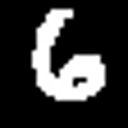

In [ ]:
from PIL import Image


Image.fromarray(np.where(X_train[0] > 0., 255., 0.)).resize([128, 128]).show()